In [1]:
import numpy as np
import matplotlib.pyplot as plt

Best Fit Parameters:
m = 2.0138 ± 0.0566
c = 0.1081 ± 0.2105
Chi-square = 0.4317
Reduced Chi-square = 0.1079


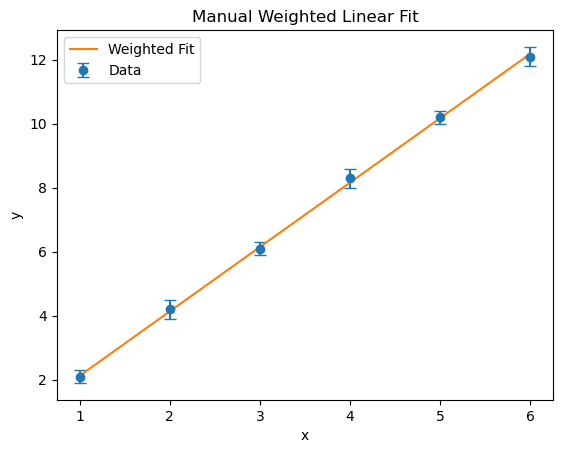

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------
# 1. Data (replace with yours)
# -------------------------
x = np.array([1, 2, 3, 4, 5, 6], dtype=float)
y = np.array([2.1, 4.2, 6.1, 8.3, 10.2, 12.1], dtype=float)
sigma = np.array([0.2, 0.3, 0.2, 0.3, 0.2, 0.3], dtype=float)

# -------------------------
# 2. Construct Matrices
# -------------------------
X = np.vstack((x, np.ones(len(x)))).T   # Design matrix
W = np.diag(1 / sigma**2)               # Weight matrix

# -------------------------
# 3. Weighted Least Squares Solution
# -------------------------
XT_W = X.T @ W
beta = np.linalg.inv(XT_W @ X) @ XT_W @ y

m, c = beta

# -------------------------
# 4. Covariance Matrix
# -------------------------
cov_matrix = np.linalg.inv(XT_W @ X)

m_err = np.sqrt(cov_matrix[0, 0])
c_err = np.sqrt(cov_matrix[1, 1])

print("Best Fit Parameters:")
print(f"m = {m:.4f} ± {m_err:.4f}")
print(f"c = {c:.4f} ± {c_err:.4f}")

# -------------------------
# 5. Chi-Square
# -------------------------
residuals = y - (m*x + c)
chi_square = np.sum((residuals / sigma)**2)
dof = len(x) - 2
reduced_chi_square = chi_square / dof

print(f"Chi-square = {chi_square:.4f}")
print(f"Reduced Chi-square = {reduced_chi_square:.4f}")

# -------------------------
# 6. Plot
# -------------------------
x_fit = np.linspace(min(x), max(x), 100)
y_fit = m*x_fit + c

plt.errorbar(x, y, yerr=sigma, fmt='o', capsize=4, label="Data")
plt.plot(x_fit, y_fit, label="Weighted Fit")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title("Manual Weighted Linear Fit")
plt.show()

Slope (m) = 2.0004 ± 0.0732
Intercept (c) = 0.1217 ± 0.2231


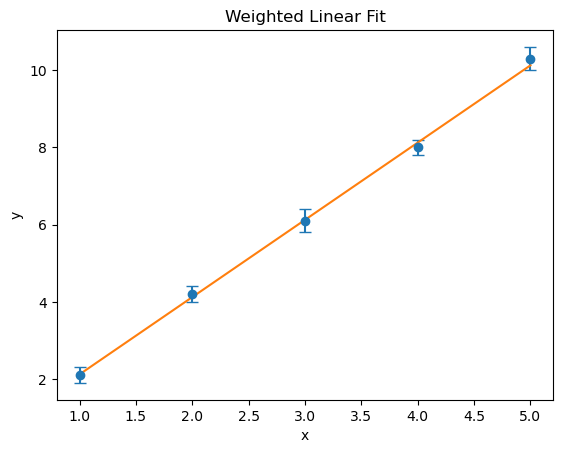

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Data (replace with yours)
x = np.array([1, 2, 3, 4, 5])
y = np.array([2.1, 4.2, 6.1, 8.0, 10.3])
sigma = np.array([0.2, 0.2, 0.3, 0.2, 0.3])  # errors in y

# Weights
w = 1 / sigma**2

# Required sums
S   = np.sum(w)
Sx  = np.sum(w * x)
Sy  = np.sum(w * y)
Sxx = np.sum(w * x * x)
Sxy = np.sum(w * x * y)

# Delta
Delta = S * Sxx - Sx**2

# Best fit parameters
m = (S * Sxy - Sx * Sy) / Delta
c = (Sxx * Sy - Sx * Sxy) / Delta

# Errors in parameters
m_err = np.sqrt(S / Delta)
c_err = np.sqrt(Sxx / Delta)

print(f"Slope (m) = {m:.4f} ± {m_err:.4f}")
print(f"Intercept (c) = {c:.4f} ± {c_err:.4f}")

# Plot
x_fit = np.linspace(min(x), max(x), 100)
y_fit = m * x_fit + c

plt.errorbar(x, y, yerr=sigma, fmt='o', capsize=4)
plt.plot(x_fit, y_fit)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Weighted Linear Fit")
plt.show()

In [ ]:
def least_fit_slope(x, y):
    n = len(x)
    XY = np.sum(w*x*y)
    X = np.sum(w*x)
    Y = np.sum(w*y)
    X2 = np.sum(w*x**2)
    m = (n*XY - X*Y)/(n*X2-(X)**2)
    return m